   Id  SepalLength  SepalWidth  PetalLength  PetalWidth      Species
0   1          5.1         3.5          1.4         0.2  Iris-setosa
1   2          4.9         3.0          1.4         0.2  Iris-setosa
2   3          4.7         3.2          1.3         0.2  Iris-setosa
3   4          4.6         3.1          1.5         0.2  Iris-setosa
4   5          5.0         3.6          1.4         0.2  Iris-setosa
(30, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Id           30 non-null     int64  
 1   SepalLength  30 non-null     float64
 2   SepalWidth   30 non-null     float64
 3   PetalLength  30 non-null     float64
 4   PetalWidth   30 non-null     float64
 5   Species      30 non-null     object 
dtypes: float64(4), int64(1), object(1)
memory usage: 1.5+ KB
None
   Id  SepalLength  SepalWidth  PetalLength  PetalWidth      Species
0   

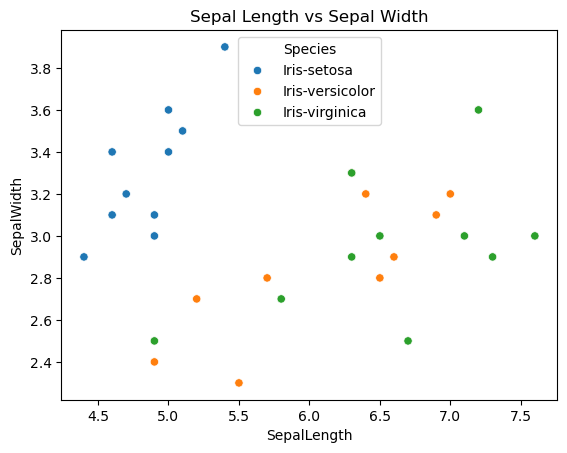

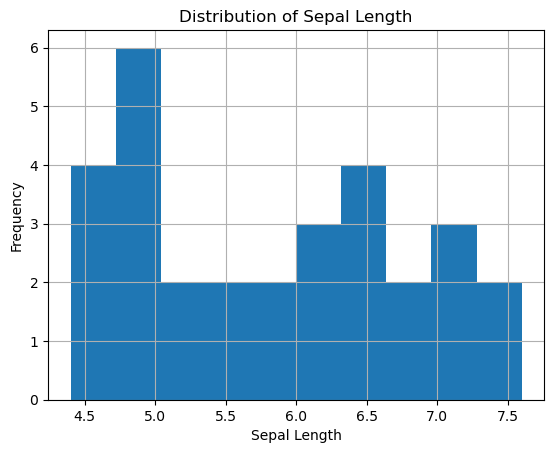

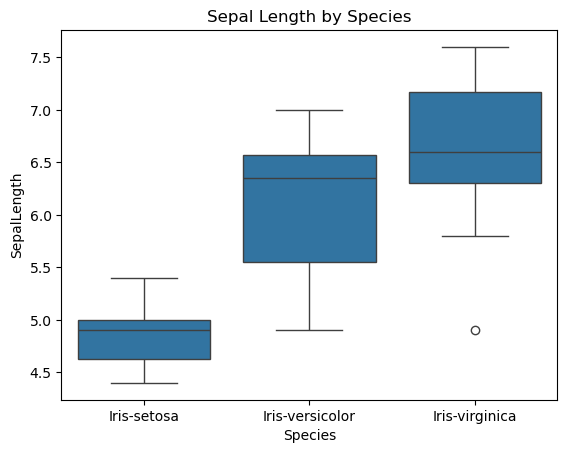

Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         2
Iris-versicolor       1.00      1.00      1.00         2
 Iris-virginica       1.00      1.00      1.00         2

       accuracy                           1.00         6
      macro avg       1.00      1.00      1.00         6
   weighted avg       1.00      1.00      1.00         6

Accuracy: 1.0000


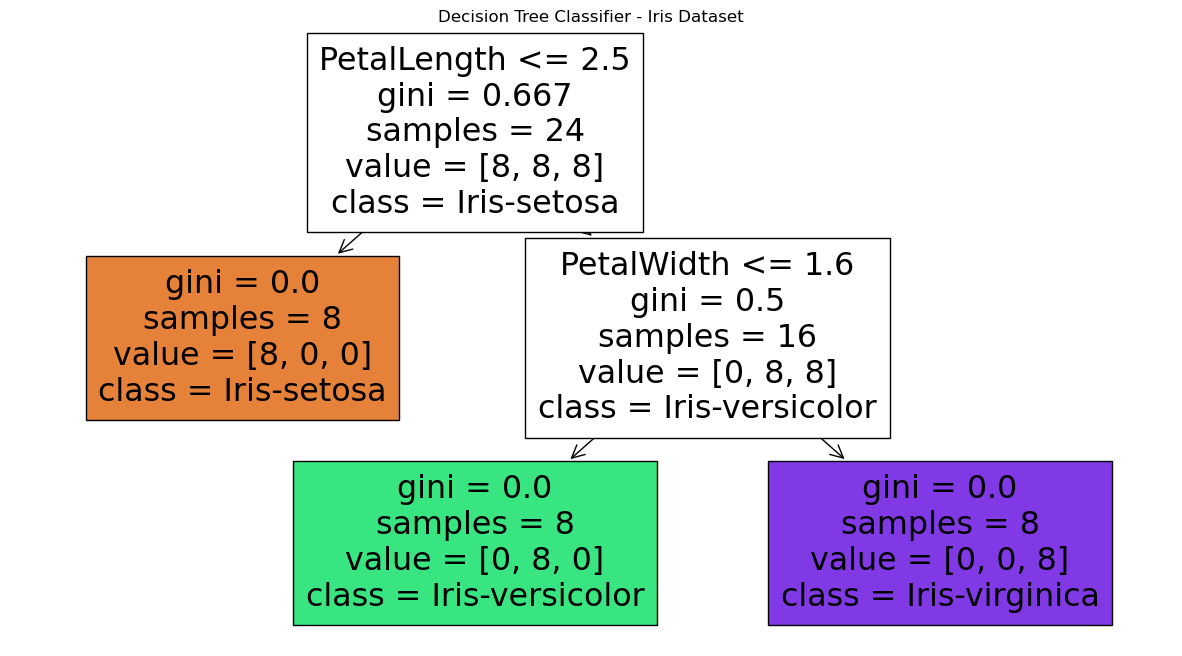

              Id  SepalLength  SepalWidth  PetalLength  PetalWidth
count  30.000000    30.000000   30.000000    30.000000   30.000000
mean   15.500000     5.843333    3.040000     3.863333    1.213333
std     8.803408     0.964073    0.372873     1.881394    0.789034
min     1.000000     4.400000    2.300000     1.300000    0.100000
25%     8.250000     4.925000    2.825000     1.500000    0.225000
50%    15.500000     5.750000    3.000000     4.500000    1.400000
75%    22.750000     6.575000    3.275000     5.475000    1.800000
max    30.000000     7.600000    3.900000     6.600000    2.500000
Id             0
SepalLength    0
SepalWidth     0
PetalLength    0
PetalWidth     0
Species        0
dtype: int64


ValueError: Could not interpret value `radius_mean` for `x`. An entry with this name does not appear in `data`.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
df = pd.read_csv("Documents/content.csv")
print(df.head())
print(df.shape)
print(df.info())
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Load dataset
df = pd.read_csv("Documents/content.csv")

# Display dataset information
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

# Remove missing values
df_cleaned = df.dropna()

# -----------------------------
# Data Visualization
# -----------------------------

# Scatter plot
sns.scatterplot(
    data=df_cleaned,
    x='SepalLength',
    y='SepalWidth',
    hue='Species'
)
plt.title("Sepal Length vs Sepal Width")
plt.show()

# Histogram
df_cleaned['SepalLength'].hist()
plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()

# Boxplot
sns.boxplot(
    data=df_cleaned,
    x='Species',
    y='SepalLength'
)
plt.title("Sepal Length by Species")
plt.show()

# -----------------------------
# Prepare data for ML
# -----------------------------

# Id is not useful for prediction, so remove it
X = df_cleaned.drop(['Species', 'Id'], axis=1)
y = df_cleaned['Species']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Decision Tree Model
# -----------------------------

dt = DecisionTreeClassifier(random_state=42)

# Train model
dt.fit(X_train, y_train)

# Make predictions
y_pred = dt.predict(X_test)

# -----------------------------
# Model Evaluation
# -----------------------------

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

# -----------------------------
# Plot Decision Tree
# -----------------------------

plt.figure(figsize=(15, 8))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=dt.classes_,
    filled=True
)

plt.title("Decision Tree Classifier - Iris Dataset")
plt.show()

print(df.describe())
print(df.isnull().sum())
df_cleaned = df.dropna()
sns.scatterplot(data=df_cleaned, x='radius_mean', y='texture_mean', hue='diagnosis')
plt.show()
df_cleaned['radius_mean'].hist()
plt.show()
sns.boxplot(data=df_cleaned, x='diagnosis', y='radius_mean')
plt.show()
X = df_cleaned.drop(['diagnosis'], axis=1)
y = df_cleaned['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
plt.figure(figsize=(15, 8))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=dt.classes_,
    filled=True
)
plt.show()
